# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The objective of this experiment is to determine whether the two carbon-fiber blade designs, Aerostep and Bionic-Flex, produce different mean 100-meter sprint times among T64 sprinters while accounting for variability between individual athletes.

2.  Specify the outcome variable and how it is measured.

The outcome variable is the 100-meter sprint time. It is a quantitative, continuous variable measured in seconds for each trial completed by the athletes.

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

The independent variables in this experiment are blade type and athlete.

Blade type is a **fixed effect** because the goal of the study is to compare these two specific blade designs, Aerostep and Bionic-Flex.

Athlete is a **random effect** because the 5 sprinters represent a sample from a larger population of T64 athletes, and we want to account for variability across athletes rather than focus only on these specific individuals.

Possible lurking variables include fatigue across repeated trials, differences in athlete training condition on the testing day, reaction time at the start, environmental conditions, and small differences in recovery time between trials.

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

A fixed effect is a factor whose specific levels are of direct interest in the experiment. In this study, blade type is a fixed effect because we want to compare the two specific designs, Aerostep and Bionic-Flex.

A random effect is a factor whose levels are considered a sample from a larger population. In this study, athlete is a random effect because the 5 sprinters represent a broader population of T64 athletes.

We account for random effects because they allow us to control for variability that is not the main focus of the study. In this case, athletes differ in biomechanics, strength, and training level, and ignoring that variation could make the comparison between blade types less accurate.

5.  State the sets of null and alternative hypotheses for this experiment.

The main hypotheses for the fixed effect of blade type are:

$$
H_0: \mu_{\text{Aerostep}} = \mu_{\text{Bionic-Flex}}
$$

$$
H_A: \mu_{\text{Aerostep}} \ne \mu_{\text{Bionic-Flex}}
$$

In words, the null hypothesis states that the two blade designs have the same mean sprint time, while the alternative hypothesis states that the mean sprint times differ between the two blade designs.

For the random effect of athlete, we are also interested in whether there is meaningful variability across athletes.

$$
H_0: \sigma^2_{\text{athlete}} = 0
$$

$$
H_A: \sigma^2_{\text{athlete}} > 0
$$

This tests whether there is any athlete-to-athlete variation that should be accounted for in the model.

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

Exploratory analysis was performed using summary statistics, boxplots, and interaction-style plots to examine how sprint times vary across blade types and athletes.

From the summary statistics, the mean sprint time for **Aerostep** is 11.260 seconds, while the mean sprint time for **Bionic-Flex** is 11.412 seconds. Since lower sprint times indicate better performance, this suggests that Aerostep performs better on average, with an improvement of about 0.152 seconds.

The boxplot comparing blade types supports this finding, as the Aerostep distribution is generally lower than the Bionic-Flex distribution. Although there is some overlap, the median sprint time for Aerostep is clearly lower, indicating faster performance.

The boxplot by athlete shows clear differences in sprint times across individuals. For example, Athlete_2 has the lowest overall times, while Athlete_1 has the highest. This indicates substantial variability between athletes, which supports treating athlete as a random effect in the model.

The boxplots by athlete and blade type, along with the mean plot, show a very consistent pattern. For all 5 athletes, the average sprint time with Aerostep is lower than with Bionic-Flex. The difference is positive for every athlete, ranging from approximately 0.097 to 0.173 seconds. This means that Aerostep outperforms Bionic-Flex for every individual athlete in the study.

The interaction-style plot shows that the lines for each athlete are roughly parallel, indicating that the effect of blade type is fairly consistent across athletes. While the magnitude of the difference varies slightly, the direction of the effect is the same for all athletes.

Overall, the exploratory analysis provides strong support for the alternative hypothesis rather than the null hypothesis, as the two blade types do not produce the same mean sprint times. In addition, there is clear variability across athletes, which justifies including athlete as a random effect in the mixed-effects model.

In [1]:
## Question 6 Code ##
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("STAT Paralympic_Blade_Experiment.xlsx")

print(df.head())
print(df.info())
print(df.columns)

  Athlete_ID   Blade_Type  Trial  Sprint_Time
0  Athlete_1     Aerostep      1        11.63
1  Athlete_1     Aerostep      2        11.57
2  Athlete_1     Aerostep      3        11.39
3  Athlete_1  Bionic-Flex      1        11.74
4  Athlete_1  Bionic-Flex      2        11.68
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete_ID   30 non-null     object 
 1   Blade_Type   30 non-null     object 
 2   Trial        30 non-null     int64  
 3   Sprint_Time  30 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB
None
Index(['Athlete_ID', 'Blade_Type', 'Trial', 'Sprint_Time'], dtype='object')


In [2]:
print("Overall Summary of Sprint Time")
print(df["Sprint_Time"].describe())

print("\nSummary by Blade Type")
print(df.groupby("Blade_Type")["Sprint_Time"].agg(["mean", "std", "min", "max"]))

print("\nSummary by Athlete")
print(df.groupby("Athlete_ID")["Sprint_Time"].agg(["mean", "std", "min", "max"]))

print("\nSummary by Athlete and Blade Type")
print(df.groupby(["Athlete_ID", "Blade_Type"])["Sprint_Time"].agg(["mean", "std", "min", "max"]))

Overall Summary of Sprint Time
count    30.000000
mean     11.336000
std       0.208055
min      10.940000
25%      11.232500
50%      11.350000
75%      11.417500
max      11.740000
Name: Sprint_Time, dtype: float64

Summary by Blade Type
               mean       std    min    max
Blade_Type                                 
Aerostep     11.260  0.199428  10.94  11.63
Bionic-Flex  11.412  0.193693  11.09  11.74

Summary by Athlete
                 mean       std    min    max
Athlete_ID                                   
Athlete_1   11.616667  0.125167  11.39  11.74
Athlete_2   11.046667  0.102697  10.94  11.19
Athlete_3   11.321667  0.063061  11.25  11.40
Athlete_4   11.390000  0.100399  11.24  11.54
Athlete_5   11.305000  0.104451  11.15  11.42

Summary by Athlete and Blade Type
                             mean       std    min    max
Athlete_ID Blade_Type                                    
Athlete_1  Aerostep     11.530000  0.124900  11.39  11.63
           Bionic-Flex  11.703333

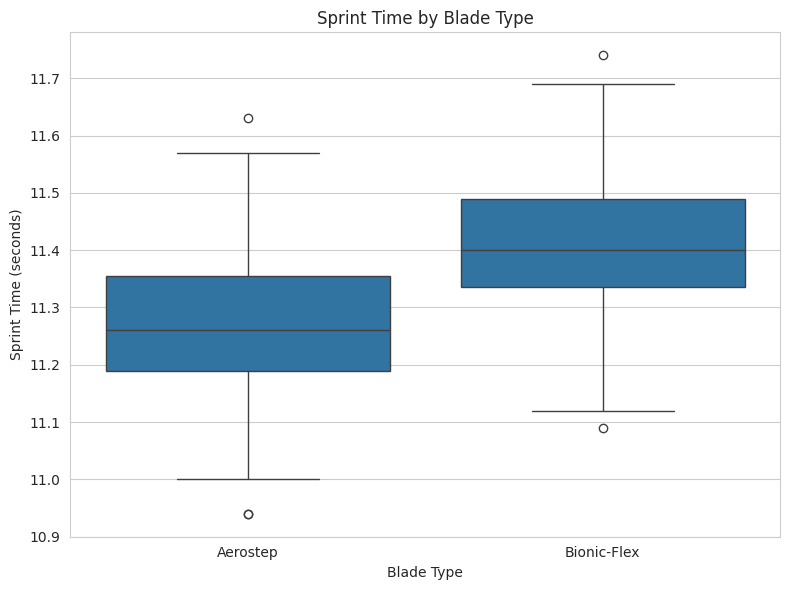

In [3]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Blade_Type", y="Sprint_Time")
plt.title("Sprint Time by Blade Type")
plt.xlabel("Blade Type")
plt.ylabel("Sprint Time (seconds)")
plt.tight_layout()
plt.show()

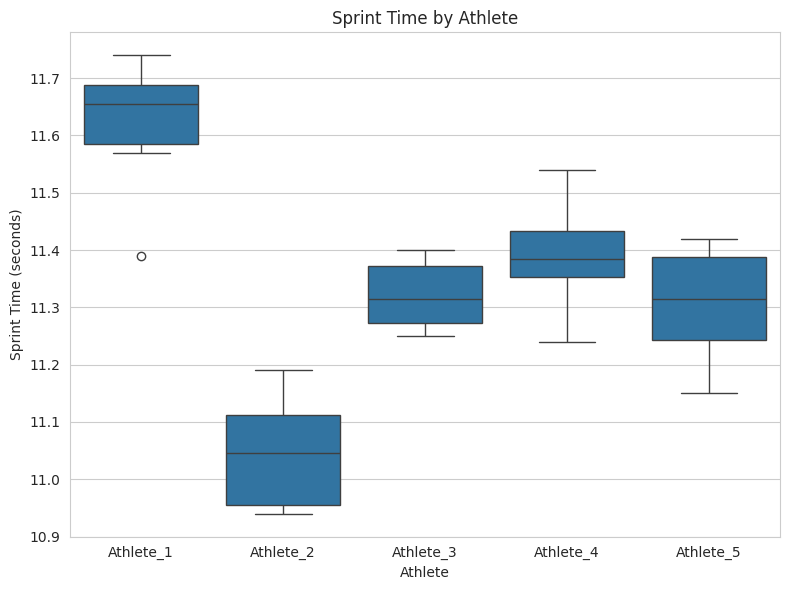

In [4]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Athlete_ID", y="Sprint_Time")
plt.title("Sprint Time by Athlete")
plt.xlabel("Athlete")
plt.ylabel("Sprint Time (seconds)")
plt.tight_layout()
plt.show()

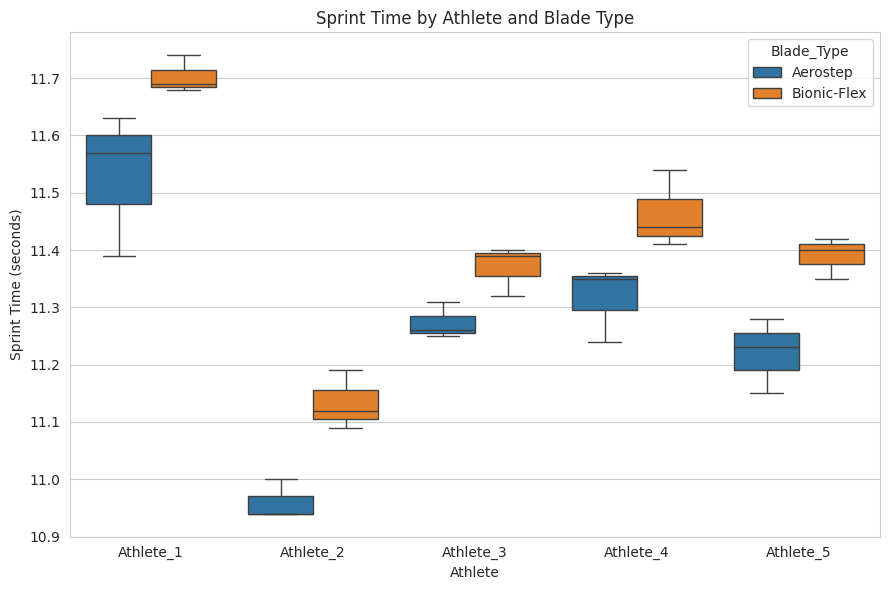

In [5]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Athlete_ID", y="Sprint_Time", hue="Blade_Type")
plt.title("Sprint Time by Athlete and Blade Type")
plt.xlabel("Athlete")
plt.ylabel("Sprint Time (seconds)")
plt.tight_layout()
plt.show()

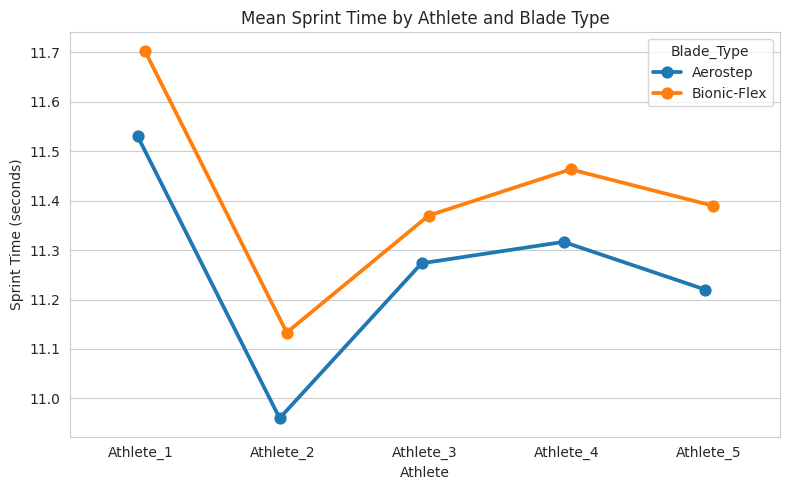

In [8]:
plt.figure(figsize=(8,5))
sns.pointplot(x="Athlete_ID", y="Sprint_Time", hue="Blade_Type", data=df, dodge=True, errorbar=None)
plt.title("Mean Sprint Time by Athlete and Blade Type")
plt.xlabel("Athlete")
plt.ylabel("Sprint Time (seconds)")
plt.tight_layout()
plt.show()

In [7]:
blade_means = df.groupby(["Athlete_ID", "Blade_Type"])["Sprint_Time"].mean().unstack()
blade_means["Bionic_minus_Aerostep"] = blade_means["Bionic-Flex"] - blade_means["Aerostep"]

print(blade_means)

Blade_Type   Aerostep  Bionic-Flex  Bionic_minus_Aerostep
Athlete_ID                                               
Athlete_1   11.530000    11.703333               0.173333
Athlete_2   10.960000    11.133333               0.173333
Athlete_3   11.273333    11.370000               0.096667
Athlete_4   11.316667    11.463333               0.146667
Athlete_5   11.220000    11.390000               0.170000


7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

A mixed-effects model was fit to the data with blade type as a fixed effect and athlete as a random effect.

The normality assumption was assessed using both a Q-Q plot of the residuals and the Shapiro–Wilk test.

From the Q-Q plot, the residuals lie very close to the reference line, with only small deviations at the extremes. There is no clear curvature or systematic pattern, which suggests that the residuals are approximately normally distributed.

The Shapiro–Wilk test resulted in a p-value of 0.542, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of normality. This indicates that there is no strong statistical evidence against the assumption that the residuals are normally distributed.

The sample size is relatively small (n = 30), so minor deviations from the line are expected in the Q-Q plot.

Overall, both the visual and testing methods provide strong support that the normality assumption is reasonably satisfied for this mixed-effects model.

In [9]:
## Question 7 Code ##
import statsmodels.formula.api as smf

# Mixed effects model: Blade = fixed, Athlete = random
model = smf.mixedlm(
    "Sprint_Time ~ Blade_Type",
    data=df,
    groups=df["Athlete_ID"]
)

result = model.fit()

print(result.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 REML       
No. Groups:           5           Scale:                  0.0034     
Min. group size:      6           Log-Likelihood:         28.3941    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.092 122.543 0.000 11.080 11.440
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var                  0.041    0.542                            



In [11]:
residuals = result.resid

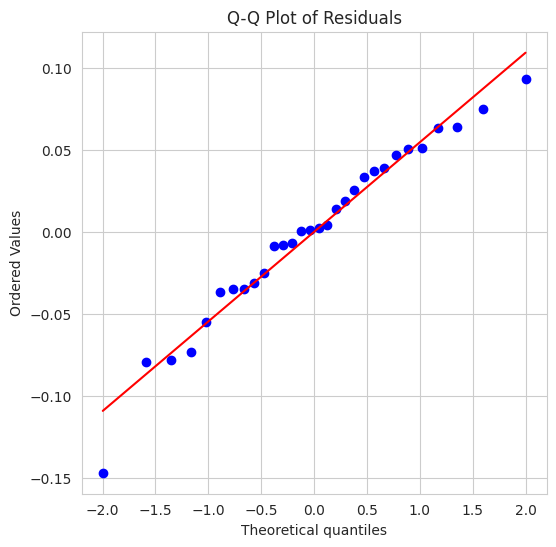

In [12]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [13]:
from scipy.stats import shapiro

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk Test")
print("Statistic:", stat)
print("p-value:", p_value)

Shapiro-Wilk Test
Statistic: 0.9701104027768613
p-value: 0.5422004847170765


8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

The constant variance assumption was assessed using both a visual method and a supporting check.

Following the lecture notes, a boxplot of standardized residuals by athlete was used as the primary visual method. From the plot, the standardized residuals appear to be centered reasonably close to zero for each athlete. The spreads are not exactly identical, but no athlete shows a dramatically larger or smaller spread than the others.

A simple numerical check of the residuals also did not indicate any clear issues with variability.

Overall, the results do not show strong evidence of unequal variance, and the constant variance assumption appears to be reasonably satisfied.

In [14]:
## Question 8 Code ##
fitted_vals = result.fittedvalues
residuals = result.resid

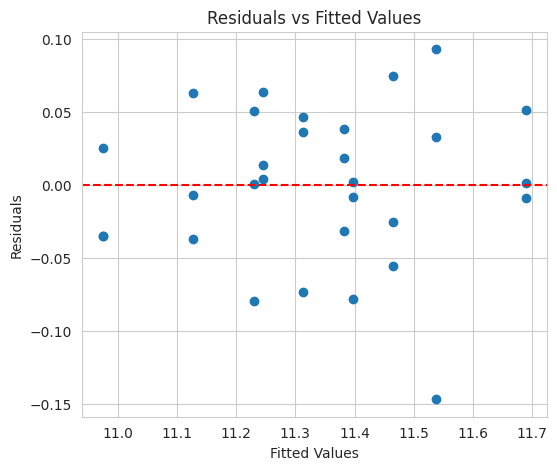

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(fitted_vals, residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

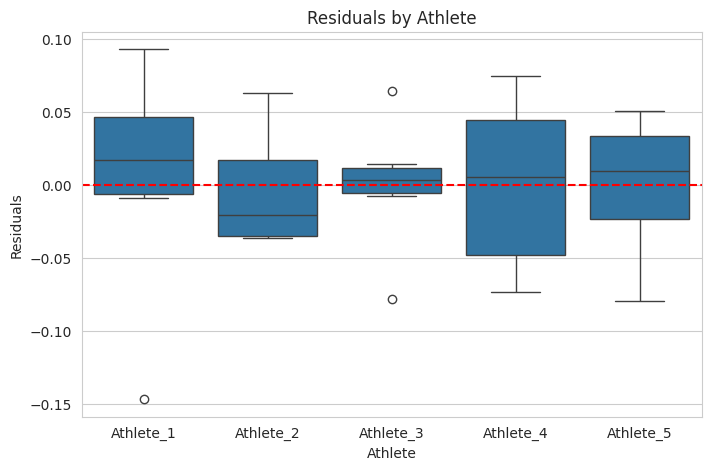

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Athlete_ID", y=residuals, data=df)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Athlete")
plt.ylabel("Residuals")
plt.title("Residuals by Athlete")
plt.show()

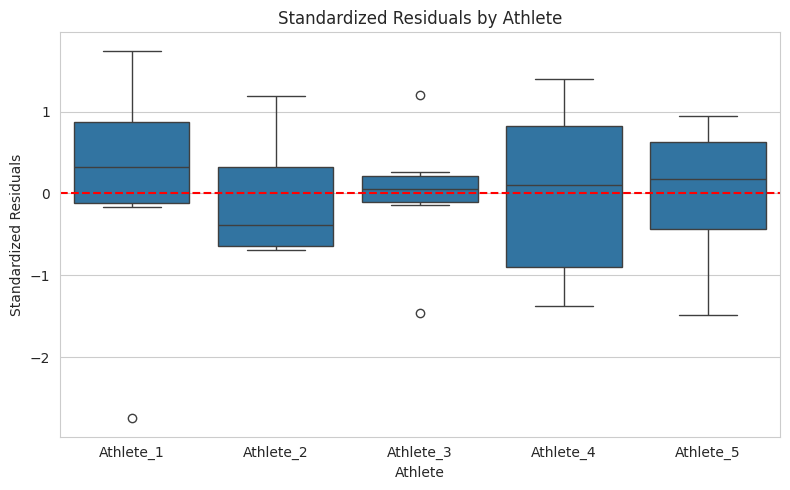

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Residuals from mixed model
residuals = result.resid

# Standardized residuals
std_residuals = (residuals - np.mean(residuals)) / np.std(residuals, ddof=1)

# Boxplot by athlete
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Athlete_ID"], y=std_residuals)

plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Athlete")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals by Athlete")

plt.tight_layout()
plt.show()

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

To evaluate the significance of the random effect of athlete, a likelihood ratio (LR) test was performed by comparing the full mixed-effects model (including the random effect) to a reduced model without the random effect.

The hypotheses for the random effect are:

\[
H_0: \sigma^2_{\text{athlete}} = 0
\]

\[
H_A: \sigma^2_{\text{athlete}} > 0
\]

The LR test resulted in a statistic of 51.19 with a p-value of approximately \(8.39 \times 10^{-13}\), which is far less than 0.05.

Since the p-value is extremely small, we reject the null hypothesis. This provides very strong evidence that there is meaningful variability in sprint times across athletes.

The estimated random effect variance for athlete is approximately 0.0328, indicating that differences between athletes contribute to the overall variation in sprint times.

Overall, the data strongly support the alternative hypothesis, showing that the random effect of athlete is important and should be included in the model.

In [19]:
## Question 9 Code ##
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm, ols
from scipy.stats import chi2

# Full mixed-effects model: Blade Type fixed effect + Athlete random effect
full_model = mixedlm(
    "Sprint_Time ~ Blade_Type",
    data=df,
    groups=df["Athlete_ID"]
).fit(reml=False)

# Reduced model: Blade Type fixed effect only, no random athlete effect
reduced_model = ols(
    "Sprint_Time ~ Blade_Type",
    data=df
).fit()

# Likelihood Ratio Test
lr_stat = 2 * (full_model.llf - reduced_model.llf)
p_value = chi2.sf(lr_stat, df=1)

print("Full model log-likelihood:", full_model.llf)
print("Reduced model log-likelihood:", reduced_model.llf)
print("Likelihood Ratio Statistic:", lr_stat)
print("p-value:", p_value)

# Random effect variance estimate
print("\nRandom effect variance for Athlete:")
print(full_model.cov_re)

Full model log-likelihood: 32.861630729122794
Reduced model log-likelihood: 7.267082504026941
Likelihood Ratio Statistic: 51.189096450191705
p-value: 8.388326332872207e-13

Random effect variance for Athlete:
          Group
Group  0.032763


10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

To evaluate the fixed effect of blade type, we examine the results from the mixed-effects model.

The hypotheses for the fixed effect are:

\[
H_0: \mu_{\text{Aerostep}} = \mu_{\text{Bionic-Flex}}
\]

\[
H_A: \mu_{\text{Aerostep}} \ne \mu_{\text{Bionic-Flex}}
\]

From the mixed-effects model, the estimated coefficient for Blade_Type[T.Bionic-Flex] is 0.152, with a z-value of 7.095 and a p-value of approximately \(1.30 \times 10^{-12}\).

This indicates that, on average, sprint times using Bionic-Flex are about 0.152 seconds higher than those using Aerostep. Since higher sprint times indicate worse performance, this means Aerostep results in faster sprint times.

Because the p-value is extremely small (much less than 0.05), we reject the null hypothesis. This provides very strong evidence that the mean sprint times differ between the two blade designs.

Overall, the data strongly support the alternative hypothesis, indicating that blade type has a significant effect on sprint performance, with Aerostep outperforming Bionic-Flex.

In [21]:
## Question 10 Code ##
import statsmodels.formula.api as smf

mixed_model = smf.mixedlm(
    "Sprint_Time ~ Blade_Type",
    data=df,
    groups=df["Athlete_ID"]
)

mixed_result = mixed_model.fit()

# Print model summary
print(mixed_result.summary())

# Extract fixed effect estimate and p-value for Bionic-Flex
coef = mixed_result.params["Blade_Type[T.Bionic-Flex]"]
p_value = mixed_result.pvalues["Blade_Type[T.Bionic-Flex]"]

print("\nFixed Effect Result:")
print("Blade_Type[T.Bionic-Flex] coefficient:", coef)
print("p-value:", p_value)
z_value = mixed_result.tvalues["Blade_Type[T.Bionic-Flex]"]

print("z-value:", z_value)

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 REML       
No. Groups:           5           Scale:                  0.0034     
Min. group size:      6           Log-Likelihood:         28.3941    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.092 122.543 0.000 11.080 11.440
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var                  0.041    0.542                            


Fixed Effect Result:
Blade_Type[T.Bionic-Flex] coefficient: 0.15199999999999983
p-value: 1.2959926827147

11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.

### Final Conclusion

Based on the mixed-effects analysis, there is strong evidence that blade type has a significant effect on 100-meter sprint times. The results show that the Aerostep blade produces faster sprint times compared to the Bionic-Flex blade, with an average improvement of about 0.152 seconds. In addition, there is significant variability across athletes, which confirms the importance of including athlete as a random effect in the model.

### Limitations

This study has a few limitations. First, the sample size is relatively small, with only 5 athletes included, which may limit how well the results generalize to the broader population of T64 sprinters. Second, although multiple trials were conducted, factors such as fatigue, recovery time between runs, and day-to-day performance variation may still affect the results. Third, the experiment only compares two blade designs, so the findings are limited to these specific models.

### Future Directions

Future studies could include a larger and more diverse group of athletes to improve generalizability. It would also be useful to test additional blade designs to expand the comparison. In addition, incorporating more controlled conditions, such as standardized recovery times or environmental settings, could help reduce variability and provide more precise estimates of performance differences.